# Voltaris — EVE cell PyBaMM parameter tuning from characterization

This is Voltaris's **Step 1**: tune PyBaMM parameters for a real EVE LF105 cell using its measured characterization data (OCV, DCIR, Q_RPT).

## What this notebook does
1. Pick an EVE cell (default: cell 2 — fresh batch-1 cell at SoH 99.15 %)
2. Load its characterization data from `Char_Consolidated (1).xlsx`
3. Fit electrode stoichiometry to the measured OCV curve (PyBaMM half-cell OCPs are anchors)
4. Build PyBaMM `ParameterValues` with:
    - Q_RPT → nominal cell capacity + electrode geometry scaling
    - DCIR R₀ → contact resistance
    - OCV-fit stoichiometry → initial concentrations
5. Run a 5-cycle smoke simulation to confirm the parameters produce sensible behaviour
6. Report the tuned parameters as a per-cell PyBaMM ParameterValues snapshot

## Pipeline analogy

This is the Voltaris implementation of the [AGENT_PARAM_ID.md](../../agents/AGENT_PARAM_ID.md) workflow. The `pybamm_tuning` package does the heavy lifting; this notebook is the human-readable orchestration.

In [1]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from pathlib import Path
import os, sys, warnings
warnings.filterwarnings('ignore')
REPO = Path.cwd()
while not (REPO / 'CLAUDE.md').exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.switch_backend('module://matplotlib_inline.backend_inline')

from pybamm_tuning import (
    load_characterization, list_available_cells,
    fit_stoichiometry_from_ocv, build_pybamm_parameters,
    Simulation, CyclingProtocol,
    summarise_overrides,
)

## 1. Pick the EVE cell to tune

Loaded characterization for EVE cell 2:
  cohort:        EVE
  Q_RPT:         104.111 Ah
  Nominal Q:     105.0 Ah
  SoH:           99.15 %
  OCV anchors:   11  (V 2.500-3.579)
  DCIR anchors:  3  (R0 0.388-0.754 mΩ)
  HPPC anchors:  9


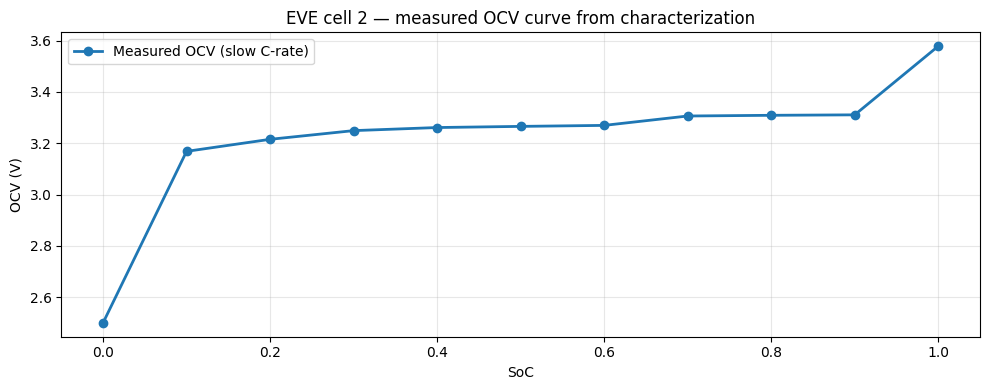

In [2]:
# Pick one cell — change EVE_CELL_ID to retarget; 'aggregate=True' for cohort median.
EVE_CELL_ID = '2'   # cell 2 has SoH 99.15 %, full char data, fresh

char = load_characterization(manufacturer='EVE', cell_id=EVE_CELL_ID)
print(f'Loaded characterization for EVE cell {EVE_CELL_ID}:')
print(f'  cohort:        {char.cohort}')
print(f'  Q_RPT:         {char.q_rpt_ah:.3f} Ah')
print(f'  Nominal Q:     {char.nominal_capacity_ah} Ah')
print(f'  SoH:           {char.soh_pct:.2f} %')
print(f'  OCV anchors:   {char.ocv_soc_grid.size}  (V {char.ocv_v_curve.min():.3f}-{char.ocv_v_curve.max():.3f})')
print(f'  DCIR anchors:  {char.dcir_soc_grid.size}  (R0 {char.dcir_r0_mohm.min():.3f}-{char.dcir_r0_mohm.max():.3f} mΩ)')
print(f'  HPPC anchors:  {char.hppc_soc_grid.size}')

# Quick OCV visualization
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(char.ocv_soc_grid, char.ocv_v_curve, marker='o', lw=2, color='#1f77b4',
        label='Measured OCV (slow C-rate)')
ax.set_xlabel('SoC'); ax.set_ylabel('OCV (V)')
ax.set_title(f'EVE cell {EVE_CELL_ID} — measured OCV curve from characterization')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); display(fig); plt.close(fig)

## 2. Fit electrode stoichiometry from OCV

Stoichiometry fit (base = Prada2013):
  x_100 (graphite full):  0.8347
  x_0   (graphite empty): 0.1701
  y_100 (LFP full):       0.0043
  y_0   (LFP empty):      0.9894
  RMSE: 6.56 mV over 11 OCV anchors
  Quality: GOOD


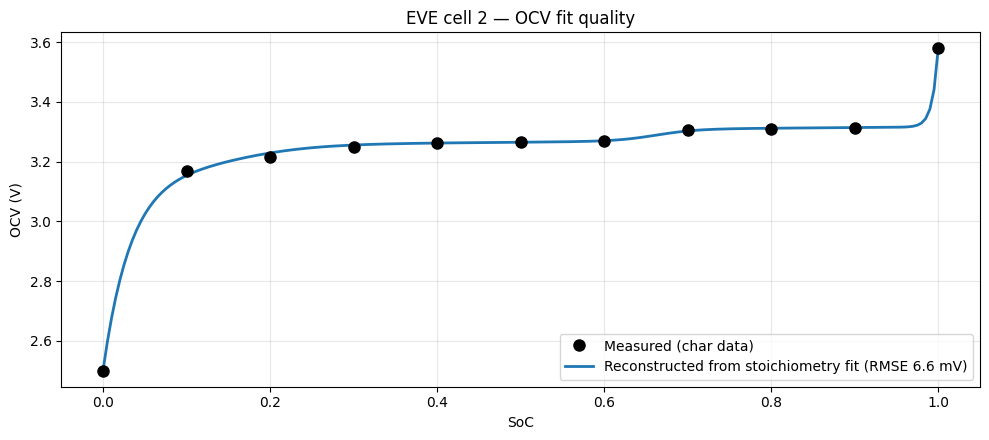

In [3]:
# This is the OCV-fit step: optimise (x_100, x_0, y_100, y_0) so PyBaMM's
# half-cell OCPs combined match the measured full-cell OCV.
fit = fit_stoichiometry_from_ocv(char.ocv_soc_grid, char.ocv_v_curve, base='Prada2013')
print(f'Stoichiometry fit (base = Prada2013):')
print(f'  x_100 (graphite full):  {fit.x_100:.4f}')
print(f'  x_0   (graphite empty): {fit.x_0:.4f}')
print(f'  y_100 (LFP full):       {fit.y_100:.4f}')
print(f'  y_0   (LFP empty):      {fit.y_0:.4f}')
print(f'  RMSE: {fit.rmse_mV:.2f} mV over {fit.n_anchors} OCV anchors')
print(f'  Quality: {"GOOD" if fit.rmse_mV < 10 else "FAIR" if fit.rmse_mV < 20 else "POOR"}')

# Visualise fit quality — measured OCV vs reconstructed from the stoichiometry
import pybamm
base = pybamm.ParameterValues('Prada2013')
soc_dense = np.linspace(0, 1, 200)
x = fit.x_0 + (fit.x_100 - fit.x_0) * soc_dense
y = fit.y_0 + (fit.y_100 - fit.y_0) * soc_dense
U_n = np.array([float(base['Negative electrode OCP [V]'](float(xi))) for xi in x])
U_p = np.array([float(base['Positive electrode OCP [V]'](float(yi))) for yi in y])
V_recon = U_p - U_n

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(char.ocv_soc_grid, char.ocv_v_curve, marker='o', markersize=8, color='black',
        label='Measured (char data)', linestyle='', zorder=10)
ax.plot(soc_dense, V_recon, color='#1f77b4', lw=2,
        label=f'Reconstructed from stoichiometry fit (RMSE {fit.rmse_mV:.1f} mV)')
ax.set_xlabel('SoC'); ax.set_ylabel('OCV (V)')
ax.set_title(f'EVE cell {EVE_CELL_ID} — OCV fit quality')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)

## 3. Build the tuned PyBaMM ParameterValues

In [4]:
# Default aging overrides — EVE-sweep medians (proxy until we calibrate per-cell)
DEFAULT_AGING = {
    'k_SEI_ms':                              7.07e-15,
    'SEI_partial_molar_volume_m3mol':        1.00e-04,
    'LAM_negative_rate_s':                   2.78e-08,
}

params = build_pybamm_parameters(
    char,
    base='Prada2013',
    aging_overrides=DEFAULT_AGING,
    fit_stoichiometry=True,           # uses fit_stoichiometry_from_ocv internally
    contact_resistance_at_soc=0.5,
    temperature_K=298.15,              # 25 °C
)

# Snapshot the key tuned keys
key_summary = [
    'Nominal cell capacity [A.h]',
    'Electrode width [m]',
    'Contact resistance [Ohm]',
    'Initial concentration in negative electrode [mol.m-3]',
    'Initial concentration in positive electrode [mol.m-3]',
    'SEI kinetic rate constant [m.s-1]',
    'Ambient temperature [K]',
]
print('--- Tuned PyBaMM parameters for EVE cell ' + EVE_CELL_ID + ' ---')
for k in key_summary:
    val = params[k]
    if isinstance(val, float):
        print(f'  {k:55s}: {val:.6g}')
    else:
        print(f'  {k:55s}: {val}')
print()
print('Override summary (machine-readable):')
display(pd.DataFrame([summarise_overrides(char, aging_overrides=DEFAULT_AGING)]).T.rename(columns={0:'value'}))

--- Tuned PyBaMM parameters for EVE cell 2 ---
  Nominal cell capacity [A.h]                            : 104.111
  Electrode width [m]                                    : 13.5797
  Contact resistance [Ohm]                               : 0.000608887
  Initial concentration in negative electrode [mol.m-3]  : 25504.5
  Initial concentration in positive electrode [mol.m-3]  : 97.6962
  SEI kinetic rate constant [m.s-1]                      : 7.07e-15
  Ambient temperature [K]                                : 298.15

Override summary (machine-readable):


,value
source,2
is_module,False
Q_RPT_per_cell_Ah,104.111
R0_at_50pct_SoC_mOhm,0.608887
SoH_pct,99.153333
OCV_top_V,3.578511
OCV_bot_V,2.5
aging_overrides,"{'k_SEI_ms': 7.07e-15, 'SEI_partial_molar_volu..."


## 4. Smoke-test — 5-cycle simulation with the tuned parameters

Confirms PyBaMM accepts the parameter set and produces a sensible SoH trajectory. Cycling at 0.25 C / 25 °C (matches Voltaris's reference protocol).

Running 5-cycle smoke simulation for EVE cell 2...
  Completed 5 cycles  (wall time 2s)


,cycle_n,Q_Ah,SOH,dcir_mOhm
0,1,100.0224,1.0000,NaN
1,2,95.8031,0.9578,NaN
2,3,91.9741,0.9195,NaN
3,4,88.4960,0.8848,NaN
4,5,85.3345,0.8532,NaN


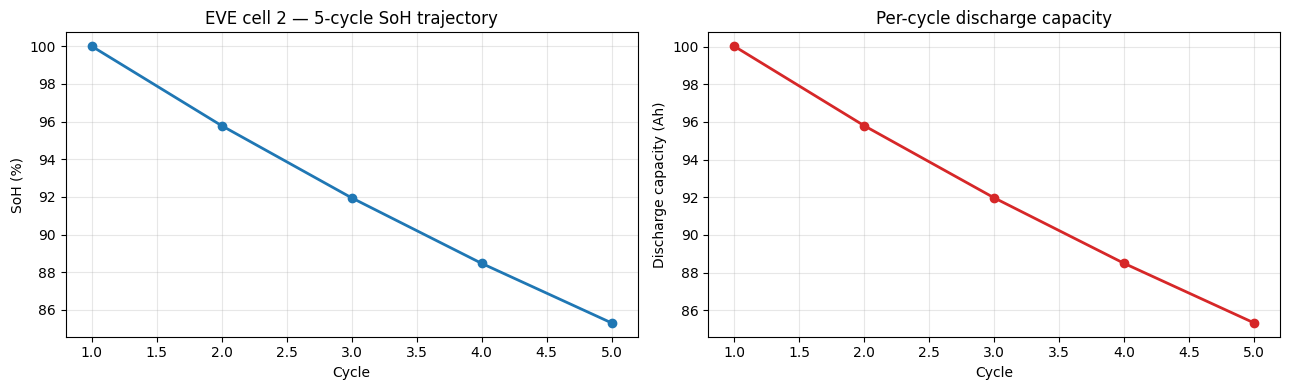

In [5]:
CACHE_DIR = Path('Voltaris/outputs/pybamm_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

sim = Simulation(params,
                  protocol=CyclingProtocol(c_rate=0.25, discharge_cut_V=2.5, charge_cut_V=3.65),
                  cache_dir=CACHE_DIR)
print(f'Running 5-cycle smoke simulation for EVE cell {EVE_CELL_ID}...')
df_sim = sim.run(n_cycles=5)
print(f'  Completed {len(df_sim)} cycles  (wall time {df_sim["wall_time_s"].iloc[0]:.0f}s)')

display(df_sim[['cycle_n','Q_Ah','SOH','dcir_mOhm']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df_sim['cycle_n'], df_sim['SOH']*100, marker='o', lw=2, color='#1f77b4')
axes[0].set_xlabel('Cycle'); axes[0].set_ylabel('SoH (%)')
axes[0].set_title(f'EVE cell {EVE_CELL_ID} — 5-cycle SoH trajectory'); axes[0].grid(alpha=0.3)
axes[1].plot(df_sim['cycle_n'], df_sim['Q_Ah'], marker='o', lw=2, color='#d62728')
axes[1].set_xlabel('Cycle'); axes[1].set_ylabel('Discharge capacity (Ah)')
axes[1].set_title('Per-cycle discharge capacity'); axes[1].grid(alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)

## 5. Persist the tuned parameters

In [6]:
import json

out_dir = Path('Voltaris/outputs/tuned_params')
out_dir.mkdir(parents=True, exist_ok=True)

# Save a JSON snapshot of just the keys we touched (PyBaMM-portable)
snapshot = {
    'cell':                 f'EVE_{EVE_CELL_ID}',
    'soh_pct':              char.soh_pct,
    'q_rpt_ah':             char.q_rpt_ah,
    'stoichiometry_fit': {
        'x_100': fit.x_100, 'x_0': fit.x_0,
        'y_100': fit.y_100, 'y_0': fit.y_0,
        'ocv_rmse_mV': fit.rmse_mV,
    },
    'pybamm_overrides': {
        'Nominal cell capacity [A.h]':                          float(params['Nominal cell capacity [A.h]']),
        'Electrode width [m]':                                   float(params['Electrode width [m]']),
        'Contact resistance [Ohm]':                              float(params['Contact resistance [Ohm]']),
        'Initial concentration in negative electrode [mol.m-3]': float(params['Initial concentration in negative electrode [mol.m-3]']),
        'Initial concentration in positive electrode [mol.m-3]': float(params['Initial concentration in positive electrode [mol.m-3]']),
        'SEI kinetic rate constant [m.s-1]':                     float(params['SEI kinetic rate constant [m.s-1]']),
        'Ambient temperature [K]':                               float(params['Ambient temperature [K]']),
        'Initial temperature [K]':                               float(params['Initial temperature [K]']),
    },
    'aging_overrides_used': DEFAULT_AGING,
    'smoke_test': {
        'cycles_run':      len(df_sim),
        'soh_cycle_1':     float(df_sim['SOH'].iloc[0]),
        'soh_cycle_last':  float(df_sim['SOH'].iloc[-1]),
        'q_ah_cycle_1':    float(df_sim['Q_Ah'].iloc[0]),
    },
}
out_path = out_dir / f'EVE_{EVE_CELL_ID}_pybamm_params.json'
out_path.write_text(json.dumps(snapshot, indent=2))
print(f'Saved -> {out_path}')

df_sim.to_parquet(out_dir / f'EVE_{EVE_CELL_ID}_smoke_5cy.parquet')
print(f'Saved -> {out_dir / f"EVE_{EVE_CELL_ID}_smoke_5cy.parquet"}')

Saved -> Voltaris/outputs/tuned_params/EVE_2_pybamm_params.json
Saved -> Voltaris/outputs/tuned_params/EVE_2_smoke_5cy.parquet


## 6. What's next in the Voltaris pipeline

This notebook produces a **per-cell tuned PyBaMM parameter set** anchored on real characterization data — Step 1 of Voltaris.

Subsequent Voltaris notebooks will:
- **Step 2** — sweep parameters (k_SEI, plating, LAM) across plausible ranges to generate **synthetic degradation trajectories** for PINN pre-training
- **Step 3** — train the Voltaris PINN on the synthetic trajectories with PyBaMM physics as a soft loss constraint
- **Step 4** — fine-tune the trained network on real longterm cycling data for the specific chemistry

## 7. Compare against actual longterm cycling data for the same EVE cell

The 5-cycle smoke test above uses **sweep-median aging constants** as a placeholder. Compare the simulated trajectory against the **real measured longterm SoH** for the same EVE cell — this tells us how well the placeholder aging parameters match reality before we calibrate them per-cell.

In [7]:
# Load longterm cycling CSV for this EVE cell + compute per-cycle SoH
LONGTERM_CSV = Path(f'Data/Longterm/EVE_Longterm_cell_000{EVE_CELL_ID}.csv')
print(f'Loading {LONGTERM_CSV}...')
lt = pd.read_csv(LONGTERM_CSV)
print(f'  {len(lt):,} rows, cycles {lt["cycle_no"].min()}-{lt["cycle_no"].max()}, max_cap={lt["max_cap"].iloc[0]} Ah')
print(f'  Cycling protocol: {lt["crate"].iloc[0]} / {lt["drate"].iloc[0]}, DoD={lt["dod"].iloc[0]}')

# Per-cycle measured SoH = discharge Ah / nominal
NOMINAL_AH = float(lt['max_cap'].iloc[0])
lt['step_name'] = lt['step_name'].astype(str)
dchg = lt[lt['step_name'].str.contains('DChg|Discharge', case=False)]
# capacity_ah is signed (negative during discharge); use min-max range
per_cycle_dchg = dchg.groupby('cycle_no')['capacity_ah'].agg(lambda s: float(np.abs(s).max() - np.abs(s).min())).reset_index()
per_cycle_dchg.columns = ['cycle_no', 'dchg_cap_ah']
per_cycle_dchg['soh_pct'] = per_cycle_dchg['dchg_cap_ah'] / NOMINAL_AH * 100
print(f'\nMeasured longterm: {len(per_cycle_dchg)} cycles, SoH range {per_cycle_dchg["soh_pct"].min():.2f}-{per_cycle_dchg["soh_pct"].max():.2f}%')

# Linear fade rate (measured)
slope_pp_per_cy = float(np.polyfit(per_cycle_dchg['cycle_no'], per_cycle_dchg['soh_pct'], 1)[0])
print(f'Measured fade slope: {slope_pp_per_cy:+.4f} pp/cycle  ({slope_pp_per_cy*100:+.2f} pp/100cy)')

# Simulated fade rate (from smoke test)
sim_slope_pp_per_cy = float(np.polyfit(df_sim['cycle_n'], df_sim['SOH']*100, 1)[0])
print(f'Simulated fade slope (5-cycle smoke): {sim_slope_pp_per_cy:+.4f} pp/cycle  ({sim_slope_pp_per_cy*100:+.2f} pp/100cy)')
print(f'Ratio (sim / measured): {sim_slope_pp_per_cy / slope_pp_per_cy:.1f}×')

Loading Data/Longterm/EVE_Longterm_cell_0002.csv...


  3,248,244 rows, cycles 1-150, max_cap=105 Ah
  Cycling protocol: 0.5C / 0.5D, DoD=0_100

Measured longterm: 150 cycles, SoH range 98.50-99.34%
Measured fade slope: -0.0035 pp/cycle  (-0.35 pp/100cy)
Simulated fade slope (5-cycle smoke): -3.6675 pp/cycle  (-366.75 pp/100cy)
Ratio (sim / measured): 1040.3×


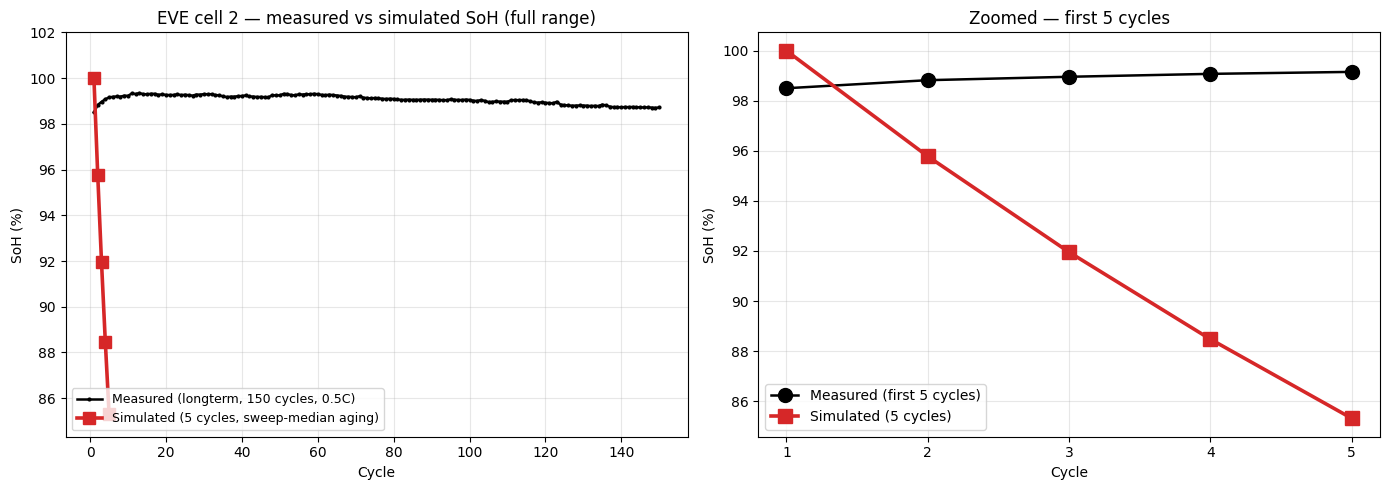

Saved -> Voltaris/outputs/tuned_params/EVE_2_sim_vs_measured.png
Saved -> Voltaris/outputs/tuned_params/EVE_2_longterm_per_cycle.csv

=== Conclusion ===
⚠ Simulated fade is 1040× too aggressive vs measured.
  → Aging constants (k_SEI, plating, LAM) need per-cell calibration (next Voltaris notebook).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full longterm trajectory + simulated overlaid
ax = axes[0]
ax.plot(per_cycle_dchg['cycle_no'], per_cycle_dchg['soh_pct'],
        color='black', lw=1.8, marker='.', markersize=4,
        label=f'Measured (longterm, {len(per_cycle_dchg)} cycles, {lt["crate"].iloc[0]})')
ax.plot(df_sim['cycle_n'], df_sim['SOH']*100,
        color='#d62728', lw=2.6, marker='s', markersize=8,
        label=f'Simulated (5 cycles, sweep-median aging)')
ax.set_xlabel('Cycle')
ax.set_ylabel('SoH (%)')
ax.set_title(f'EVE cell {EVE_CELL_ID} — measured vs simulated SoH (full range)')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(min(per_cycle_dchg['soh_pct'].min(), df_sim['SOH'].min()*100) - 1, 102)

# Right: zoomed to first 5 cycles for direct comparison
ax = axes[1]
ax.plot(per_cycle_dchg['cycle_no'][:5], per_cycle_dchg['soh_pct'][:5],
        color='black', lw=1.8, marker='o', markersize=10,
        label='Measured (first 5 cycles)')
ax.plot(df_sim['cycle_n'], df_sim['SOH']*100,
        color='#d62728', lw=2.6, marker='s', markersize=10,
        label='Simulated (5 cycles)')
ax.set_xlabel('Cycle')
ax.set_ylabel('SoH (%)')
ax.set_title('Zoomed — first 5 cycles')
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout(); display(fig); plt.close(fig)

# Save comparison
out = Path('Voltaris/outputs/tuned_params')
fig.savefig(out / f'EVE_{EVE_CELL_ID}_sim_vs_measured.png', dpi=120, bbox_inches='tight')
per_cycle_dchg.to_csv(out / f'EVE_{EVE_CELL_ID}_longterm_per_cycle.csv', index=False)
print(f'Saved -> {out / f"EVE_{EVE_CELL_ID}_sim_vs_measured.png"}')
print(f'Saved -> {out / f"EVE_{EVE_CELL_ID}_longterm_per_cycle.csv"}')

# Headline message
print()
print('=== Conclusion ===')
ratio = sim_slope_pp_per_cy / slope_pp_per_cy if slope_pp_per_cy != 0 else float('inf')
if abs(ratio) > 10:
    print(f'⚠ Simulated fade is {abs(ratio):.0f}× too aggressive vs measured.')
    print('  → Aging constants (k_SEI, plating, LAM) need per-cell calibration (next Voltaris notebook).')
elif abs(ratio) > 2:
    print(f'⚠ Simulated fade is {abs(ratio):.1f}× the measured rate — within an order of magnitude but needs calibration.')
else:
    print(f'✓ Simulated fade is {abs(ratio):.1f}× measured — sweep-median aging is approximately right.')